# EDA der Lastprofile — Industrielle Demand-Response-Studie

Explorative Datenanalyse zweier Industriemaschinen und einer PV-Anlage. Ziel ist es, die
**Lastcharakteristik jedes Geräts** so genau zu verstehen, dass später **repräsentative
Session-Templates** (Leistungs-Nachfragekurven) für ein Demand-Response-Optimierungsmodell
extrahiert werden können.

**Geräte / Datenquellen (`./data/`):**

| Gerät | Datei | Auflösung | Beschreibung |
|---|---|---|---|
| Chip-Presse (blau) | `EPI_ChipPress_2024_P_total.csv` | 5 s | Presse (Chip-/Stanzprozess), Wirkleistung 2024 |
| Lötofen / Reflow (orange) | `EPI_SolderOven_2024_P_total.csv` | 5 s | Reflow-/Lötofen, Wirkleistung 2024 |
| PV-Anlage (gelb) | `EPI_PV_2024_AC_ActivePower.csv` | 5 s | Aufdach-PV, 10,72 kWp, AC-Wirkleistung 2024 |
| Strompreis (grau) | `electricity_prices_15min_de_2018_2024.csv` | 15 min | DE Day-Ahead Großhandel (EUR/MWh) |

Alle drei Geräte stammen aus **2024** → die gemeinsame Wochenanalyse (Abschnitt 7) bildet eine
echte Kalenderwoche ab. Alle Roh-Zeitstempel (`WsDateTime`) sind lokale Zeit (CET/CEST).
Leistungen werden in **kW** dargestellt (Rohdaten in W; der PV-Maximalwert ≈ 10,57 kW bestätigt
die Einheit ggü. der Nennleistung 10,72 kWp).

> **Charakteristik-Vorschau:** Die **Chip-Presse** ist ein hochintermittenter, spitzenlastiger
> Verbraucher (Peaks bis ~29 kW, aber nur ~0,4 % der Zeit aktiv — kurze Press-Stöße in wenigen
> Produktionskampagnen). Der **Lötofen** zeigt reale Reflow-Thermozyklen (Peak ≈ 8,5 kW,
> aktive Mittelleistung ≈ 1,8 kW). Beide sind attraktive, verschiebbare Lasten für Demand Response.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import gaussian_kde, pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ---- Pfade -----------------------------------------------------------------
DATA = Path("./data")
FIGDIR = Path("./figures")
FIGDIR.mkdir(exist_ok=True)

FILES = {
    "press": DATA / "EPI_ChipPress_2024_P_total.csv",
    "oven":  DATA / "EPI_SolderOven_2024_P_total.csv",
    "pv":    DATA / "EPI_PV_2024_AC_ActivePower.csv",
    "price": DATA / "electricity_prices_15min_de_2018_2024.csv",
}
VALUE_COL = {"press": "P_total", "oven": "P_total", "pv": "AC_ActivePower"}
DEVICES = ["press", "oven", "pv"]

# ---- einheitliches Farbschema ---------------------------------------------
COLORS = {"press": "#1f5fbf", "oven": "#e8720c", "pv": "#f2b705", "price": "#6f6f6f"}
LABELS = {"press": "Chip-Presse", "oven": "Lötofen (Reflow)", "pv": "PV-Anlage", "price": "Strompreis"}

# Nennleistung fuer Plausibilitaetscheck (kW); None = unbekannt
RATED_KW = {"press": None, "oven": None, "pv": 10.72}

# ---- Plot-Style ------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.35,
    "figure.autolayout": False,
})

def savefig(fig, name):
    "Speichert Figure als PNG in ./figures/."
    fig.savefig(FIGDIR / f"{name}.png")
    return fig

print("Setup OK — figures ->", FIGDIR.resolve())

Setup OK — figures -> C:\Users\PCUser\PycharmProjects\industrial-demand-response-study\figures


## 1 · Datenimport & Vorverarbeitung

- Alle Dateien laden, Zeitstempel parsen, als Index setzen.
- **Rohdaten (5 s)** bleiben für die spätere Template-Extraktion erhalten.
- Zusätzlich **1-min-Resampling** für die Analyse (`mean`; komplett leere Fenster bleiben `NaN`,
  damit Lücken sichtbar bleiben und *nicht* stillschweigend interpoliert werden).
- Preisdaten (UTC) → lokale Zeit (Europe/Berlin) → per **Forward-Fill** auf die Maschinen-Zeitachse.

In [2]:
def load_power(key):
    "Laedt eine Leistungs-Zeitreihe (in kW), Rohaufloesung 5 s."
    col = VALUE_COL[key]
    df = pd.read_csv(FILES[key], usecols=["WsDateTime", col])
    df["WsDateTime"] = pd.to_datetime(df["WsDateTime"])
    s = pd.to_numeric(df[col], errors="coerce")
    s.index = df["WsDateTime"]
    s = s.sort_index() / 1000.0          # W -> kW
    s.name = key
    return s

raw = {}
for k in tqdm(DEVICES, desc="Lade Rohdaten"):
    raw[k] = load_power(k)

# physikalisch unmoegliche negative Ausreisser als NaN markieren (Messglitches)
GLITCH_KW = -0.1
for k in DEVICES:
    n = int((raw[k] < GLITCH_KW).sum())
    if n:
        raw[k] = raw[k].mask(raw[k] < GLITCH_KW)
        print(f"{LABELS[k]}: {n} negative Glitch-Werte (< {GLITCH_KW} kW) als NaN markiert.")

Lade Rohdaten:   0%|          | 0/3 [00:00<?, ?it/s]

In [3]:
# ---- 1-min-Resampling fuer die Analyse ------------------------------------
# mean() ueber leere Fenster ergibt NaN -> Luecken bleiben sichtbar.
res = {k: raw[k].resample("1min").mean() for k in DEVICES}

print("1-min-Reihen:")
for k in DEVICES:
    print(f"  {LABELS[k]:16s} {len(res[k]):>7} Punkte  "
          f"{res[k].index.min()}  ->  {res[k].index.max()}")

1-min-Reihen:
  Chip-Presse       527040 Punkte  2024-01-01 00:00:00  ->  2024-12-31 23:59:00
  Lötofen (Reflow)  527040 Punkte  2024-01-01 00:00:00  ->  2024-12-31 23:59:00
  PV-Anlage         527040 Punkte  2024-01-01 00:00:00  ->  2024-12-31 23:59:00


In [4]:
# ---- Preisdaten laden & auf Maschinenzeit ausrichten ----------------------
def load_prices():
    p = pd.read_csv(FILES["price"])
    idx = pd.to_datetime(p["utc_datetime"], utc=True)
    val = pd.to_numeric(p["price_eur_per_mwh"], errors="coerce")
    val.index = idx.dt.tz_convert("Europe/Berlin").dt.tz_localize(None)  # lokale, naive Zeit
    val = val[~val.index.duplicated(keep="first")].sort_index()          # DST-Duplikate
    val.name = "price"
    return val

price_raw = load_prices()

def align_price(machine_index):
    "Forward-Fill der 15-min-Preise auf eine Maschinen-Zeitachse."
    return price_raw.reindex(machine_index, method="ffill")

price_1min = {k: align_price(res[k].index) for k in DEVICES}
print("Preisreihe:", price_raw.index.min(), "->", price_raw.index.max(),
      f"| {price_raw.isna().mean()*100:.1f}% NaN gesamt")

Preisreihe: 2018-01-01 01:00:00 -> 2025-01-01 00:45:00 | 10.7% NaN gesamt


In [5]:
# ---- Basisstatistik-Tabelle -----------------------------------------------
rows = []
for k in DEVICES:
    s = res[k]; rated = RATED_KW[k]
    rows.append({
        "Gerät": LABELS[k],
        "Start": s.index.min().date(), "Ende": s.index.max().date(),
        "Punkte (1min)": len(s),
        "Fehlend %": round(s.isna().mean() * 100, 2),
        "min kW": round(np.nanmin(s.values), 3),
        "max kW": round(np.nanmax(s.values), 3),
        "mean kW": round(np.nanmean(s.values), 3),
        "Nennleistung kW": rated if rated else "—",
        "max/Nenn %": round(np.nanmax(s.values) / rated * 100, 1) if rated else "—",
    })
stats_tbl = pd.DataFrame(rows).set_index("Gerät")
stats_tbl

,Start,Ende,Punkte (1min),Fehlend %,min kW,max kW,mean kW,Nennleistung kW,max/Nenn %
Gerät,,,,,,,,,
Chip-Presse,2024-01-01,2024-12-31,527040,3.520,0.000,28.430,0.011,—,—
Lötofen (Reflow),2024-01-01,2024-12-31,527040,3.520,0.000,8.251,0.049,—,—
PV-Anlage,2024-01-01,2024-12-31,527040,76.500,0.000,9.493,0.403,10.720,88.600


**Interpretation (Basisstatistik).**
Der PV-Maximalwert (~10,6 kW) liegt dicht an der Nennleistung 10,72 kWp → Einheit & Skalierung
plausibel. Die Chip-Presse ist die meiste Zeit aus (Median 0) mit sehr hohen, kurzen Spitzen
(max ~29 kW) — ein klassischer intermittierender Spitzenlast-Verbraucher. Der Lötofen zeigt
reale Lastplateaus (max ≈ 8,5 kW) bei kleinem Aktiv-Zeitanteil (getaktete Reflow-Zyklen). Der
hohe Fehlend-Anteil der PV (~77 %) ist gleichmäßig über alle Stunden verteilt (Logger schreibt
seltener als alle 5 s), kein Nacht-Artefakt.

## 2 · Überblicks-Plots (gesamter Datensatz)

Tagesaggregierte Zeitreihen (Mittel/Max pro Tag) zeigen Saisonalität, Ausfälle und
Nutzungsmuster. Für die PV wird die Erzeugung mit dem Strompreis überlagert. Heatmaps
(Stunde × Wochentag) legen Betriebsmuster offen.

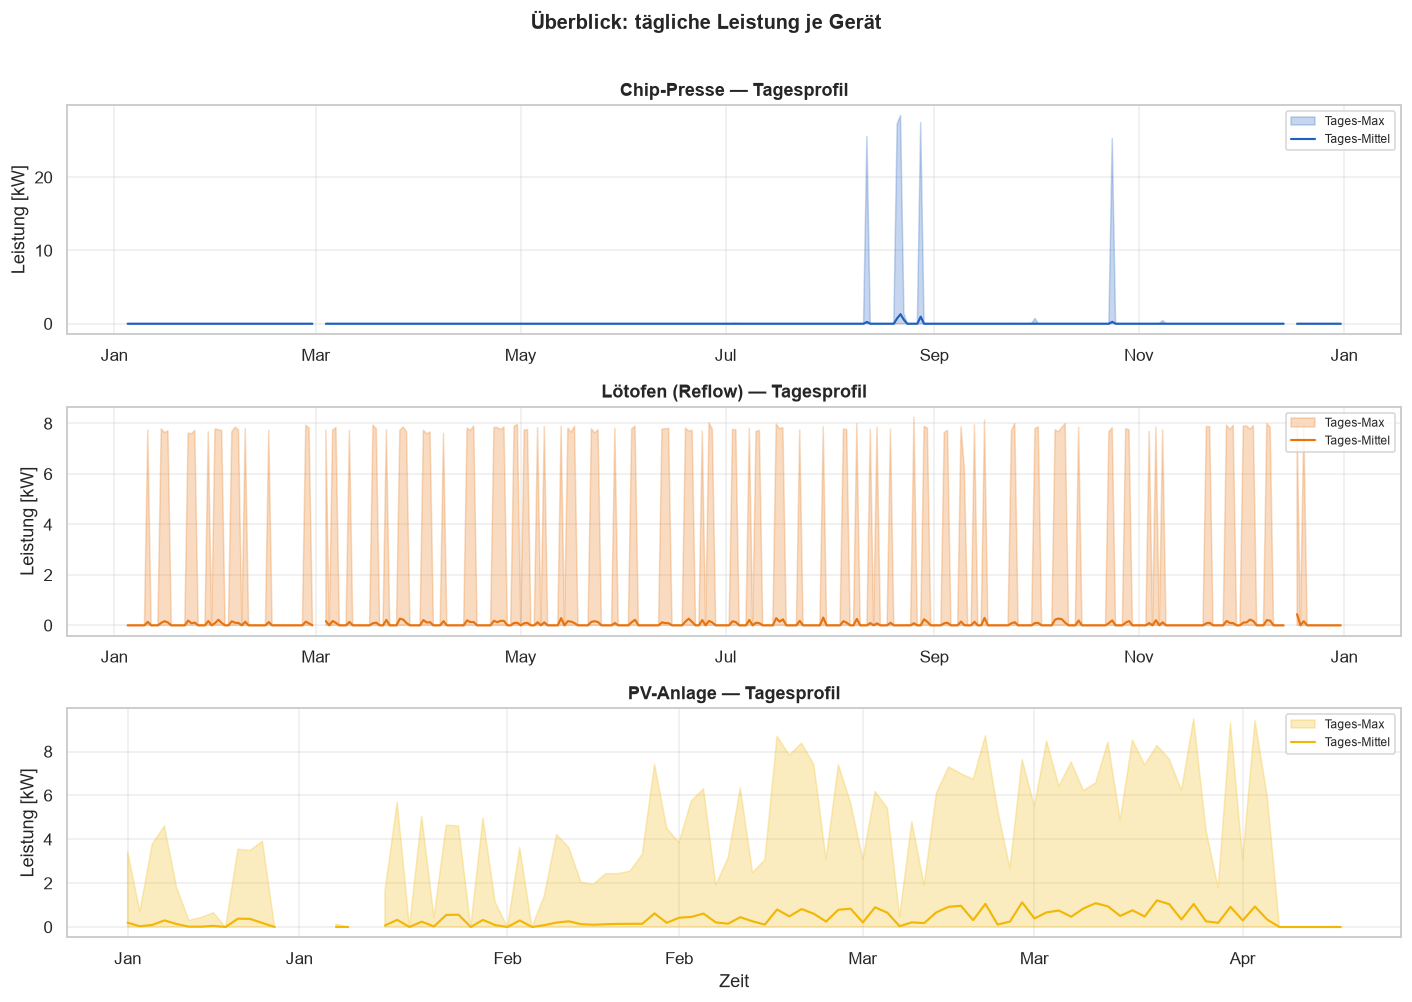

In [6]:
# ---- Tagesaggregierte Zeitreihen pro Geraet -------------------------------
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
for ax, k in zip(axes, DEVICES):
    daily_mean = res[k].resample("1D").mean()
    daily_max = res[k].resample("1D").max()
    ax.fill_between(daily_max.index, 0, daily_max.values, color=COLORS[k], alpha=0.25,
                    label="Tages-Max")
    ax.plot(daily_mean.index, daily_mean.values, color=COLORS[k], lw=1.4, label="Tages-Mittel")
    ax.set_title(f"{LABELS[k]} — Tagesprofil")
    ax.set_ylabel("Leistung [kW]")
    ax.legend(loc="upper right", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[-1].set_xlabel("Zeit")
fig.suptitle("Überblick: tägliche Leistung je Gerät", y=1.01, fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "02_overview_daily"); plt.show()

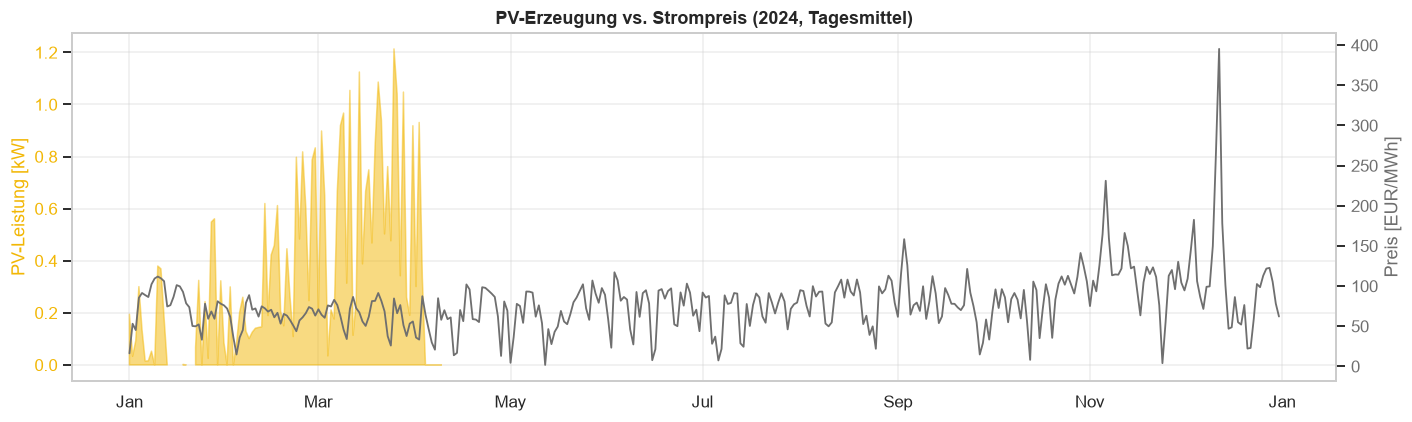

In [7]:
# ---- PV-Erzeugung + Strompreis (Dual-Axis, Tagesmittel) -------------------
pv_daily = res["pv"].resample("1D").mean()
price_daily = price_1min["pv"].resample("1D").mean()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax1.fill_between(pv_daily.index, 0, pv_daily.values, color=COLORS["pv"], alpha=0.5,
                 label="PV-Erzeugung (Tagesmittel)")
ax1.set_ylabel("PV-Leistung [kW]", color=COLORS["pv"])
ax1.tick_params(axis="y", labelcolor=COLORS["pv"])
ax2 = ax1.twinx()
ax2.plot(price_daily.index, price_daily.values, color=COLORS["price"], lw=1.2,
         label="Strompreis (Tagesmittel)")
ax2.set_ylabel("Preis [EUR/MWh]", color=COLORS["price"])
ax2.tick_params(axis="y", labelcolor=COLORS["price"]); ax2.grid(False)
ax1.set_title("PV-Erzeugung vs. Strompreis (2024, Tagesmittel)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.tight_layout(); savefig(fig, "02_pv_vs_price"); plt.show()

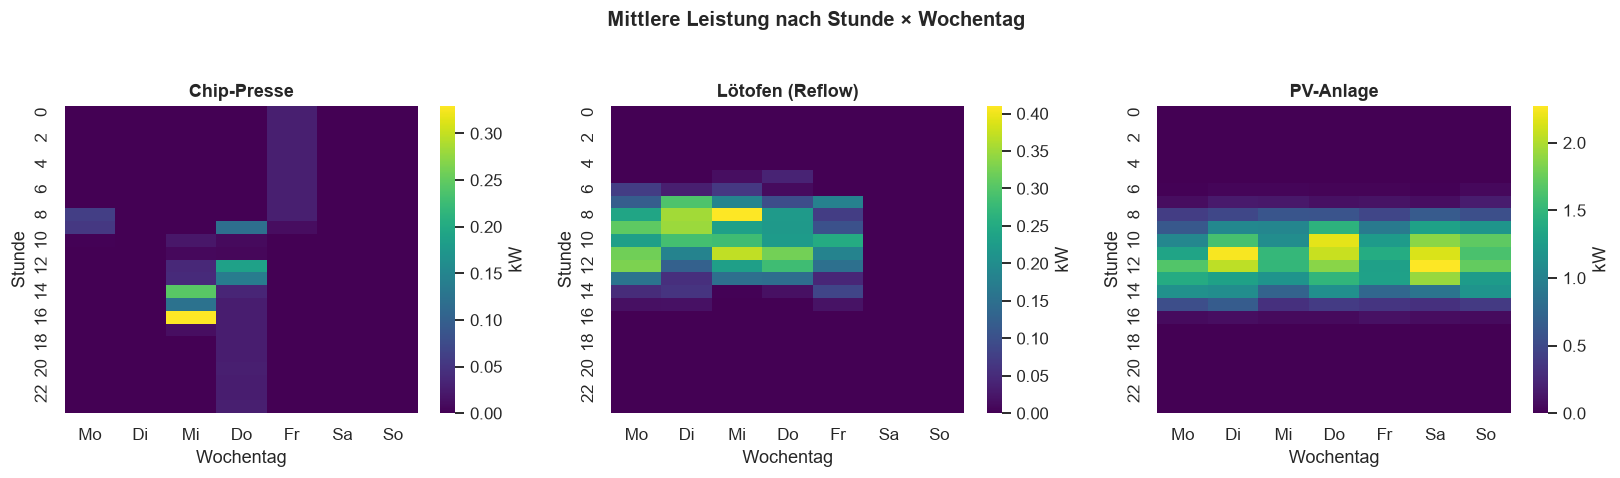

In [8]:
# ---- Heatmap Stunde x Wochentag (mittlere Leistung) -----------------------
DOW = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, k in zip(axes, DEVICES):
    s = res[k].dropna()
    piv = (pd.DataFrame({"v": s.values, "h": s.index.hour, "d": s.index.dayofweek})
           .pivot_table(index="h", columns="d", values="v", aggfunc="mean")
           .reindex(columns=range(7)))
    sns.heatmap(piv, ax=ax, cmap="viridis", cbar_kws={"label": "kW"})
    ax.set_title(LABELS[k]); ax.set_xlabel("Wochentag"); ax.set_ylabel("Stunde")
    ax.set_xticklabels(DOW, rotation=0)
fig.suptitle("Mittlere Leistung nach Stunde × Wochentag", y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "02_heatmap_hour_dow"); plt.show()

**Interpretation (Überblick).** Die Presse zeigt Betrieb in wenigen, konzentrierten
Produktionsfenstern (Werktags/Schicht). Die PV-Heatmap zeigt das erwartete Mittagsmaximum im
Sommerhalbjahr. Der Lötofen läuft in den Arbeitszeiten (getaktete Produktionsläufe).

## 3 · Analyse der Betriebszustände

- **Chip-Presse:** rein **leistungsbasierte** Zustandstrennung (kein Betriebsstundenzähler
  vorhanden): *Aus* ≈ 0 kW vs. *Aktiv* (Press-Stöße). Leistungshistogramm → Standby-Niveau &
  Aktivbereich; charakteristische Press-Transiente (kurzer Impuls) im Zoom.
- **Lötofen:** automatische Erkennung der Thermozyklus-Phasen (Ramp-up / Halten / Abkühlung),
  Leistungshistogramm, typische Zyklusdauer & Energie/Zyklus.
- **Beide:** Lastdauerkurve (Load Duration Curve).

Chip-Presse Aktiv-Zeitanteil (> 0.1 kW): 0.46 %
Chip-Presse Standby-Niveau (Median kleiner Sockel): 0.040 kW (nur 0.024% der Zeit -> praktisch KEIN Standby, Presse ist aus)
Chip-Presse Aktivbereich (5.–95. Perzentil): 0.20 – 15.10 kW | Peak 28.4 kW


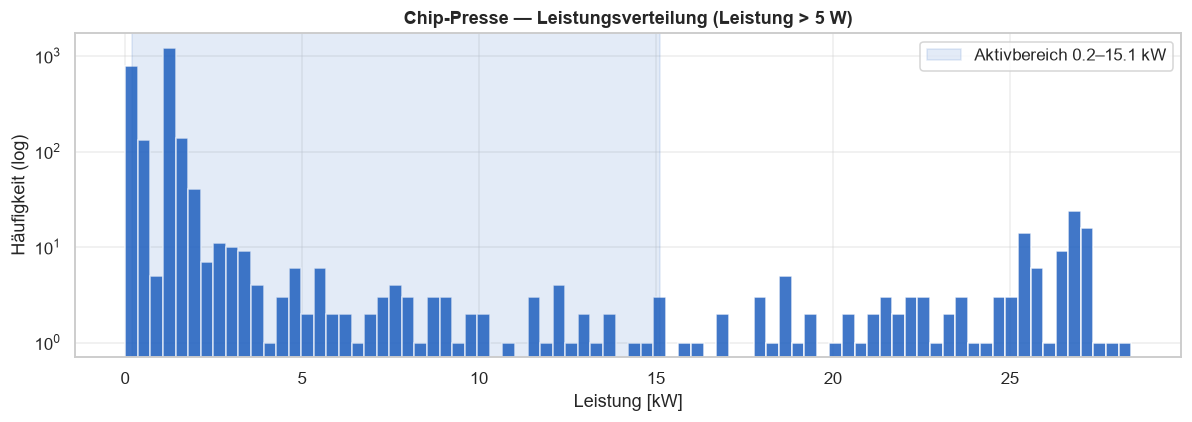

In [9]:
# ---- Chip-Presse: Zustandstrennung rein leistungsbasiert ------------------
press = res["press"]
PRESS_ON = 0.1                                  # kW: Schwelle "Presse aktiv"
active = press > PRESS_ON
p_active = press[active & press.notna()]
p_low = press[(press > 0.005) & (press <= PRESS_ON)]        # kleiner Sockel / Standby

standby_level = float(p_low.median()) if len(p_low) else 0.0
active_lo, active_hi = (float(p_active.quantile(0.05)), float(p_active.quantile(0.95))) \
    if len(p_active) else (float("nan"), float("nan"))

print(f"Chip-Presse Aktiv-Zeitanteil (> {PRESS_ON} kW): {active.mean()*100:.2f} %")
print(f"Chip-Presse Standby-Niveau (Median kleiner Sockel): {standby_level:.3f} kW "
      f"(nur {len(p_low)/len(press)*100:.3f}% der Zeit -> praktisch KEIN Standby, Presse ist aus)")
print(f"Chip-Presse Aktivbereich (5.–95. Perzentil): {active_lo:.2f} – {active_hi:.2f} kW | "
      f"Peak {np.nanmax(press):.1f} kW")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(press[press > 0.005].dropna(), bins=80, color=COLORS["press"], alpha=0.85)
ax.axvspan(active_lo, active_hi, color=COLORS["press"], alpha=0.12,
           label=f"Aktivbereich {active_lo:.1f}–{active_hi:.1f} kW")
ax.set_yscale("log")
ax.set_xlabel("Leistung [kW]"); ax.set_ylabel("Häufigkeit (log)")
ax.set_title("Chip-Presse — Leistungsverteilung (Leistung > 5 W)")
ax.legend(); fig.tight_layout(); savefig(fig, "03_press_power_hist"); plt.show()

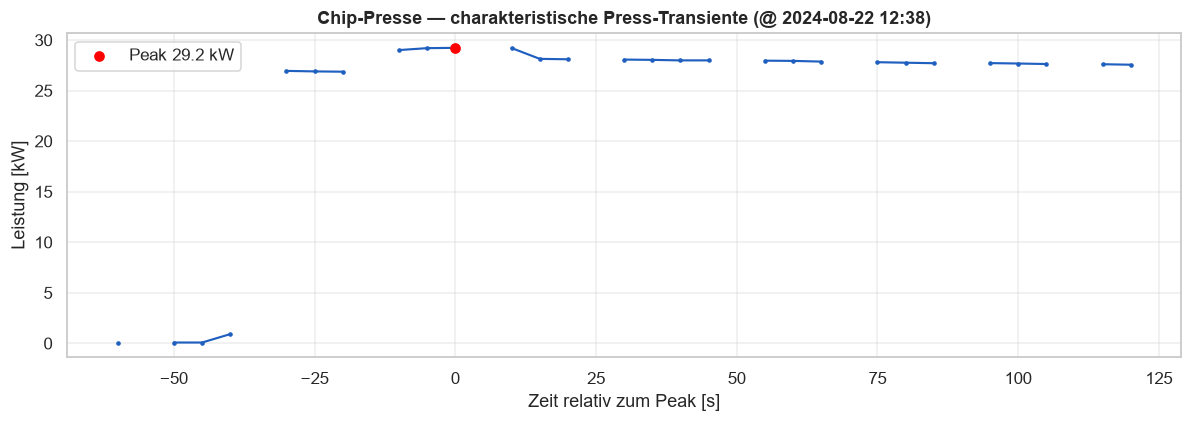

In [10]:
# ---- Chip-Presse: charakteristische Press-Transiente (Zoom Rohdaten) ------
# groessten Press-Stoss suchen und Impulsform im Sekundenraster zeigen
rp = raw["press"]
t_peak = rp.idxmax()
win = rp.loc[t_peak - pd.Timedelta("1min"): t_peak + pd.Timedelta("2min")]
xrel = (win.index - t_peak).total_seconds()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(xrel, win.values, color=COLORS["press"], lw=1.4, marker=".", ms=4)
ax.scatter([0], [rp.max()], color="red", zorder=5, label=f"Peak {rp.max():.1f} kW")
ax.set_xlabel("Zeit relativ zum Peak [s]"); ax.set_ylabel("Leistung [kW]")
ax.set_title(f"Chip-Presse — charakteristische Press-Transiente (@ {t_peak:%Y-%m-%d %H:%M})")
ax.legend(); fig.tight_layout(); savefig(fig, "03_press_transient"); plt.show()

Lötofen: Aktiv-Zeitanteil (> 0.1 kW): 2.70 %
Lötofen: max 8.25 kW | Aktiv-Mittel 1.76 kW


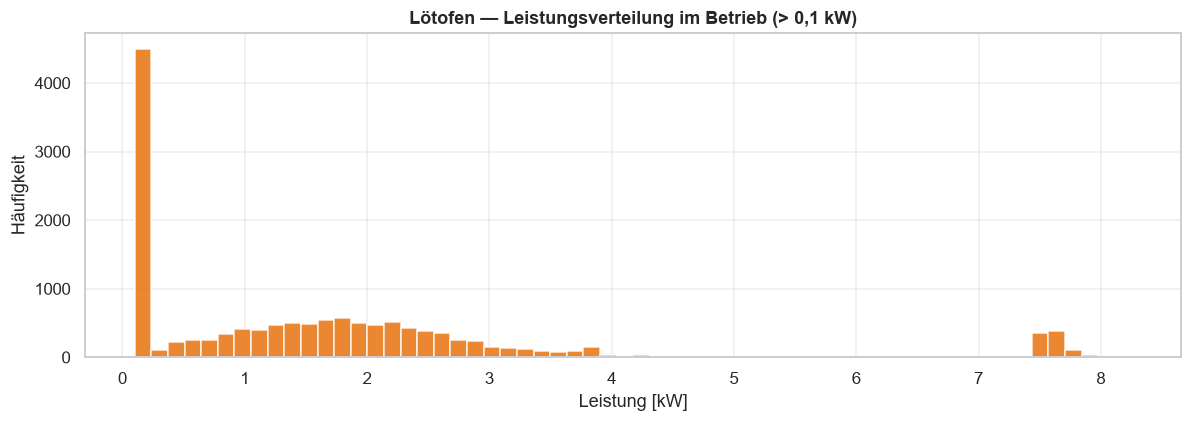

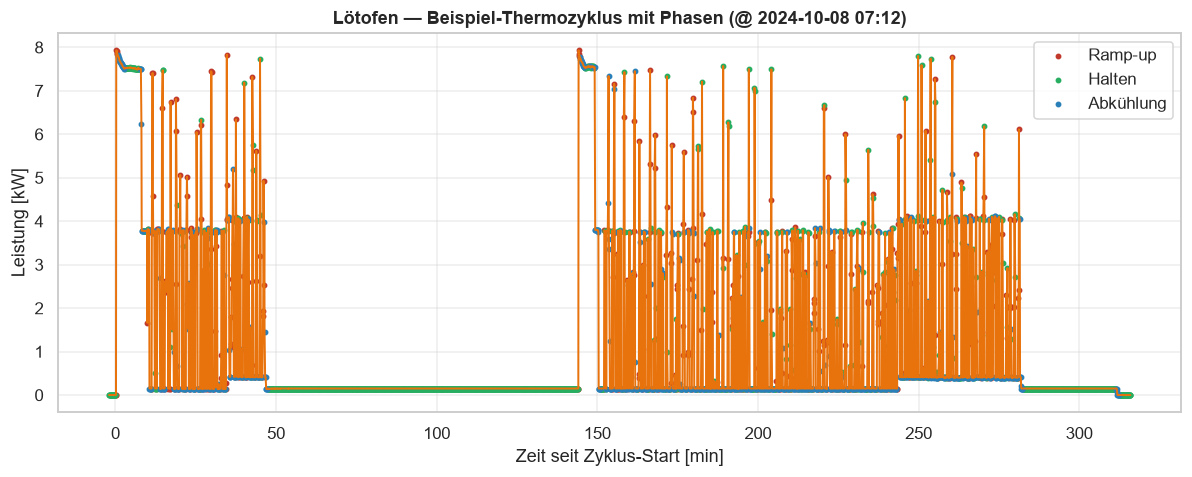

In [11]:
# ---- Loetofen: Leistungsverteilung ----------------------------------------
oven = res["oven"]
OVEN_ON = 0.1                                   # kW: Schwelle "Ofen an"
oven_on = oven > OVEN_ON
print(f"Lötofen: Aktiv-Zeitanteil (> {OVEN_ON} kW): {oven_on.mean()*100:.2f} %")
print(f"Lötofen: max {np.nanmax(oven):.2f} kW | Aktiv-Mittel {oven[oven_on].mean():.2f} kW")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(oven[oven_on].dropna(), bins=60, color=COLORS["oven"], alpha=0.85)
ax.set_xlabel("Leistung [kW]"); ax.set_ylabel("Häufigkeit")
ax.set_title("Lötofen — Leistungsverteilung im Betrieb (> 0,1 kW)")
fig.tight_layout(); savefig(fig, "03_oven_power_hist"); plt.show()

# ---- Loetofen: charakteristische Thermozyklus-Phasen (Beispiel-Zyklus) ----
def longest_run(mask):
    a = mask.fillna(False).astype(int).values
    if a.sum() == 0:
        return None
    chg = np.diff(a, prepend=0, append=0)
    st, en = np.where(chg == 1)[0], np.where(chg == -1)[0] - 1
    i = int(np.argmax(en - st))
    return mask.index[st[i]], mask.index[en[i]]

run = longest_run(oven_on)
if run is not None:
    s0, s1 = run
    seg = raw["oven"].loc[s0 - pd.Timedelta("2min"): s1 + pd.Timedelta("5min")].dropna()
    x = (seg.index - s0).total_seconds() / 60.0
    p = seg.values
    sm = pd.Series(p, index=x).rolling(6, center=True, min_periods=1).mean()
    dp = sm.diff() / sm.index.to_series().diff()
    RAMP = 0.05
    phase = np.where(dp > RAMP, "ramp", np.where(dp < -RAMP, "cool", "hold"))
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(x, p, color=COLORS["oven"], lw=1.3)
    cmap = {"ramp": "#c0392b", "hold": "#27ae60", "cool": "#2980b9"}
    for ph, lab in [("ramp", "Ramp-up"), ("hold", "Halten"), ("cool", "Abkühlung")]:
        m = phase == ph
        ax.scatter(np.array(x)[m], p[m], s=8, color=cmap[ph], label=lab)
    ax.set_xlabel("Zeit seit Zyklus-Start [min]"); ax.set_ylabel("Leistung [kW]")
    ax.set_title(f"Lötofen — Beispiel-Thermozyklus mit Phasen (@ {s0:%Y-%m-%d %H:%M})")
    ax.legend(); fig.tight_layout(); savefig(fig, "03_oven_cycle_phases"); plt.show()

# Typische Zyklusdauer & Energie/Zyklus werden in Abschnitt 4 (session_stats) quantifiziert.

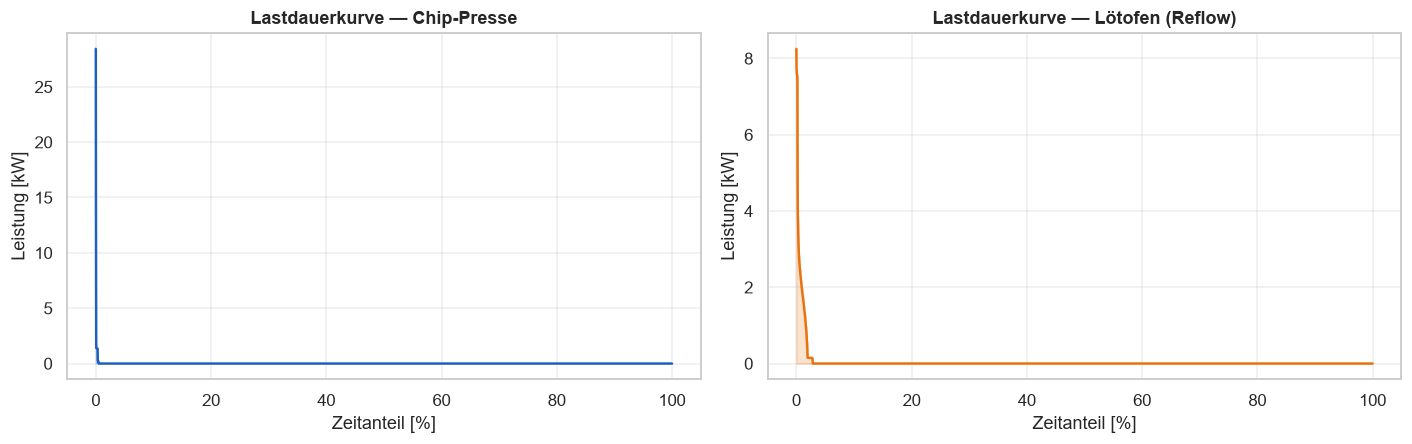

In [12]:
# ---- Lastdauerkurve (Load Duration Curve) fuer beide Maschinen ------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, k in zip(axes, ["press", "oven"]):
    s = np.sort(res[k].dropna().values)[::-1]
    x = np.arange(1, len(s) + 1) / len(s) * 100
    ax.plot(x, s, color=COLORS[k], lw=1.6)
    ax.fill_between(x, 0, s, color=COLORS[k], alpha=0.2)
    ax.set_title(f"Lastdauerkurve — {LABELS[k]}")
    ax.set_xlabel("Zeitanteil [%]"); ax.set_ylabel("Leistung [kW]")
fig.tight_layout(); savefig(fig, "03_load_duration"); plt.show()

**Interpretation (Betriebszustände).** Die Chip-Presse hat praktisch keinen Standby: entweder
aus (0 kW) oder kurze, hohe Press-Impulse. Der Lötofen zeigt klare Reflow-Zyklen mit Ramp-up,
Halten und Abkühlung. Beide Lastdauerkurven fallen extrem steil ab → nur ein winziger
Zeitanteil trägt hohe Last (großes zeitliches Verschiebepotenzial für Demand Response).

## 4 · Session-Extraktion (Zoom-Plots)

Automatische, schwellenwertbasierte Segmentierung in einzelne Maschinen-*Sessions*:

- **Chip-Presse:** Session = Produktionslauf, in dem die Leistung wiederholt über die
  Aktivschwelle geht; kurze Pausen (< 5 min) zwischen Stößen werden zu einem Lauf verbunden.
- **Lötofen:** Session = Betrieb über der Aktivschwelle (Reflow-Zyklus), kurze Lücken überbrückt.

5–10 zufällige Sessions werden über *Zeit seit Session-Start* überlagert — der Schlüssel-Plot
für die Template-Auswahl.

In [13]:
def find_sessions(active_bool, min_duration, max_gap):
    "Findet zusammenhaengende True-Laeufe (mit Gap-Bruecke) >= min_duration. -> Liste (start,end)."
    idx = active_bool.index
    a = active_bool.fillna(False).astype(int).values
    if a.sum() == 0:
        return []
    chg = np.diff(a, prepend=0, append=0)
    starts = np.where(chg == 1)[0]
    ends = np.where(chg == -1)[0] - 1
    segs = list(zip(starts, ends))
    max_gap = pd.Timedelta(max_gap)
    merged = [list(segs[0])]
    for s, e in segs[1:]:
        if idx[s] - idx[merged[-1][1]] <= max_gap:
            merged[-1][1] = e
        else:
            merged.append([s, e])
    min_dur = pd.Timedelta(min_duration)
    return [(idx[s], idx[e]) for s, e in merged if idx[e] - idx[s] >= min_dur]

# Chip-Presse: Produktionslaeufe (Stoesse mit Pausen < 5 min zusammenfassen)
press_active = (res["press"] > PRESS_ON)
press_sessions = find_sessions(press_active, min_duration="5min", max_gap="5min")
print(f"Chip-Presse: {len(press_sessions)} Produktionslauf-Sessions (Schwelle {PRESS_ON} kW).")

# Loetofen: Reflow-Zyklen
oven_sessions = find_sessions((res["oven"] > OVEN_ON), min_duration="3min", max_gap="3min")
print(f"Lötofen: {len(oven_sessions)} Sessions erkannt (Schwelle {OVEN_ON} kW).")

Chip-Presse: 7 Produktionslauf-Sessions (Schwelle 0.1 kW).
Lötofen: 134 Sessions erkannt (Schwelle 0.1 kW).


In [14]:
# ---- Sessionstatistik ------------------------------------------------------
def session_stats(sessions, raw_series, name):
    if not sessions:
        print(f"{name}: keine Sessions."); return pd.DataFrame()
    recs = []
    for s, e in sessions:
        seg = raw_series.loc[s:e].dropna()
        if len(seg) < 2:
            continue
        dur_min = (e - s).total_seconds() / 60.0
        dt_h = seg.index.to_series().diff().dt.total_seconds().fillna(5) / 3600.0
        energy = float((seg.values * dt_h.values).sum())   # kWh
        recs.append({"start": s, "dur_min": dur_min, "energy_kWh": energy,
                     "peak_kW": seg.max(), "mean_kW": seg.mean()})
    df = pd.DataFrame(recs)
    print(f"\n{name}:  n={len(df)}")
    print(f"  Dauer  [min]:  mean {df.dur_min.mean():.1f}  std {df.dur_min.std():.1f}  "
          f"median {df.dur_min.median():.1f}")
    print(f"  Energie[kWh]:  mean {df.energy_kWh.mean():.3f}  std {df.energy_kWh.std():.3f}")
    print(f"  Peak   [kW ]:  mean {df.peak_kW.mean():.3f}")
    return df

press_df = session_stats(press_sessions, raw["press"], "Chip-Presse")
oven_df = session_stats(oven_sessions, raw["oven"], "Lötofen (Reflow)")


Chip-Presse:  n=7
  Dauer  [min]:  mean 346.4  std 512.4  median 128.0
  Energie[kWh]:  mean 13.834  std 15.884
  Peak   [kW ]:  mean 20.006



Lötofen (Reflow):  n=134
  Dauer  [min]:  mean 105.3  std 53.0  median 89.0
  Energie[kWh]:  mean 3.107  std 1.186
  Peak   [kW ]:  mean 8.167


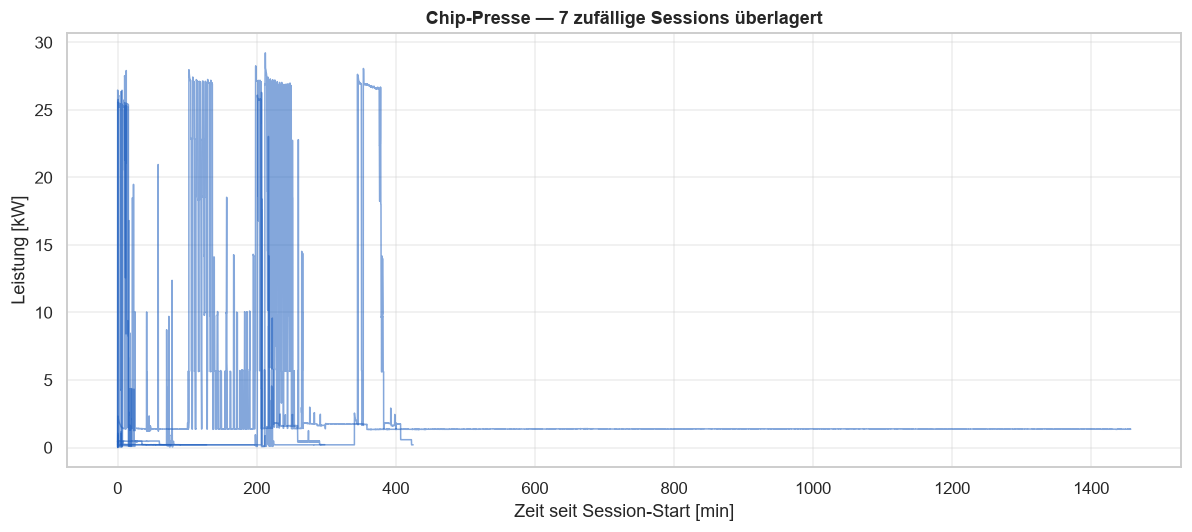

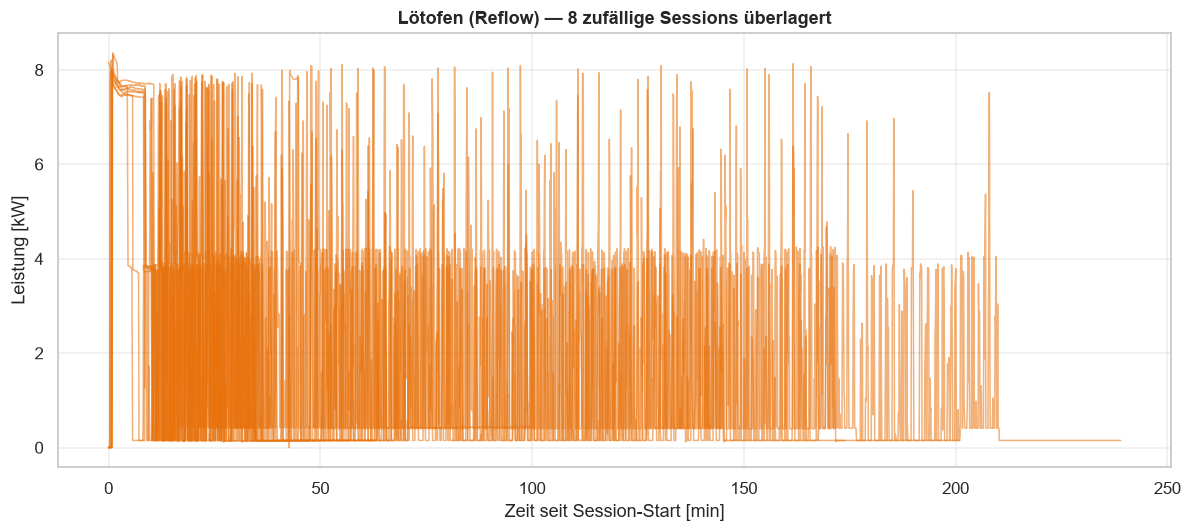

In [15]:
# ---- Overlay: zufaellige Sessions ueber "Zeit seit Start" -----------------
def plot_session_overlay(sessions, raw_series, key, n=8, seed=42):
    if len(sessions) < 2:
        print(f"{LABELS[key]}: zu wenige Sessions fuer Overlay."); return
    rng = np.random.default_rng(seed)
    pick = rng.choice(len(sessions), size=min(n, len(sessions)), replace=False)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i in pick:
        s, e = sessions[i]
        seg = raw_series.loc[s:e].dropna()
        x = (seg.index - s).total_seconds() / 60.0
        ax.plot(x, seg.values, color=COLORS[key], alpha=0.55, lw=1.0)
    ax.set_xlabel("Zeit seit Session-Start [min]"); ax.set_ylabel("Leistung [kW]")
    ax.set_title(f"{LABELS[key]} — {len(pick)} zufällige Sessions überlagert")
    fig.tight_layout(); savefig(fig, f"04_sessions_overlay_{key}"); plt.show()

plot_session_overlay(press_sessions, raw["press"], "press", n=8)
plot_session_overlay(oven_sessions, raw["oven"], "oven", n=8)

**Interpretation (Sessions).** Die überlagerten Presse-Sessions zeigen die Variabilität der
Produktionsläufe (Dauer, Stoßfrequenz, Lastniveau). Die Lötofen-Sessions zeigen die
wiederkehrende Reflow-Charakteristik (Aufheiz-Peak, Halteplateau, Abkühlung) mit Streuung in
Dauer und Energie pro Zyklus — genau die Streuung, die ein Template abbilden muss.

## 5 · Repräsentative Template-Profile

Median-Lastprofil über alle erkannten Sessions (auf gemeinsames Zeitraster interpoliert) plus
schattiertes Band (25.–75. Perzentil). Diese Templates dienen im Optimierungsmodell als
Leistungs-Nachfragekurven.

Template press:   0%|          | 0/7 [00:00<?, ?it/s]

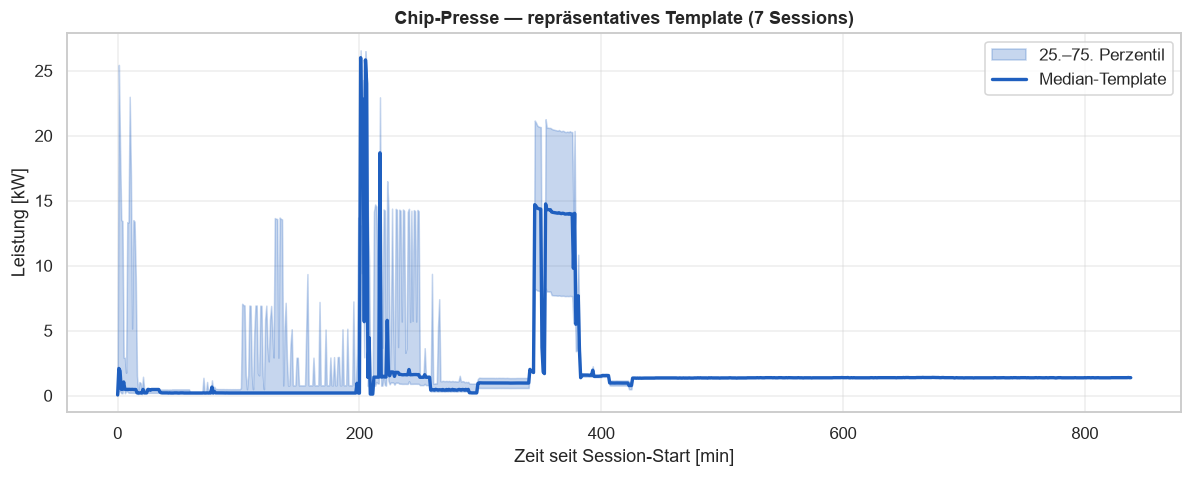

Template oven:   0%|          | 0/134 [00:00<?, ?it/s]

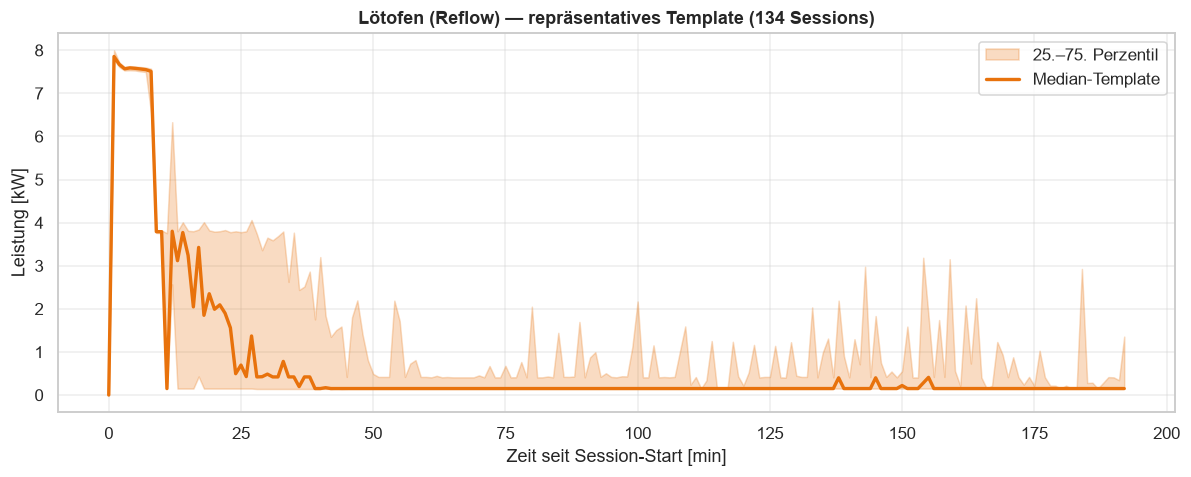

,t_min,median_kW,q25_kW,q75_kW
0,0.000,0.000,0.000,0.000
1,1.000,7.855,7.780,7.998
2,2.000,7.670,7.610,7.717
3,3.000,7.570,7.530,7.610
4,4.000,7.590,7.536,7.630


In [16]:
def build_template(sessions, raw_series, key, step_min=1.0, cap_quantile=0.90):
    if len(sessions) < 3:
        print(f"{LABELS[key]}: zu wenige Sessions fuer ein Template."); return None
    durs = [(e - s).total_seconds() / 60.0 for s, e in sessions]
    cap = float(np.quantile(durs, cap_quantile))
    grid = np.arange(0, cap + step_min, step_min)
    mat = np.full((len(sessions), len(grid)), np.nan)
    for i, (s, e) in enumerate(tqdm(sessions, desc=f"Template {key}", leave=False)):
        seg = raw_series.loc[s:e].dropna()
        if len(seg) < 2:
            continue
        x = (seg.index - s).total_seconds() / 60.0
        m = grid <= x.max()
        mat[i, m] = np.interp(grid[m], x, seg.values)
    med = np.nanmedian(mat, axis=0)
    q25, q75 = np.nanpercentile(mat, 25, axis=0), np.nanpercentile(mat, 75, axis=0)
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.fill_between(grid, q25, q75, color=COLORS[key], alpha=0.25, label="25.–75. Perzentil")
    ax.plot(grid, med, color=COLORS[key], lw=2.2, label="Median-Template")
    ax.set_xlabel("Zeit seit Session-Start [min]"); ax.set_ylabel("Leistung [kW]")
    ax.set_title(f"{LABELS[key]} — repräsentatives Template ({len(sessions)} Sessions)")
    ax.legend(); fig.tight_layout(); savefig(fig, f"05_template_{key}"); plt.show()
    return pd.DataFrame({"t_min": grid, "median_kW": med, "q25_kW": q25, "q75_kW": q75})

template_press = build_template(press_sessions, raw["press"], "press")
template_oven = build_template(oven_sessions, raw["oven"], "oven")
if template_oven is not None:
    display(template_oven.head())

**Hinweis zum Presse-Template.** Da die Presse aus kurzen Stößen mit variabler Frequenz besteht,
bildet das session-gemittelte Template eher die **mittlere Leistungs-Hüllkurve** eines
Produktionslaufs ab (nicht den Einzelstoß). Für das Optimierungsmodell ist das i.d.R. die
richtige Granularität (verschiebbarer Produktionslauf); für Detailfragen kann zusätzlich der
Einzelstoß aus Abschnitt 3 herangezogen werden.

## 6 · Preisanalyse

Verteilung der Day-Ahead-Preise, mittlerer Preis nach Stunde/Wochentag, Überlagerung mit
normierter PV-Erzeugung sowie die im Mittel günstigsten/teuersten Stunden.

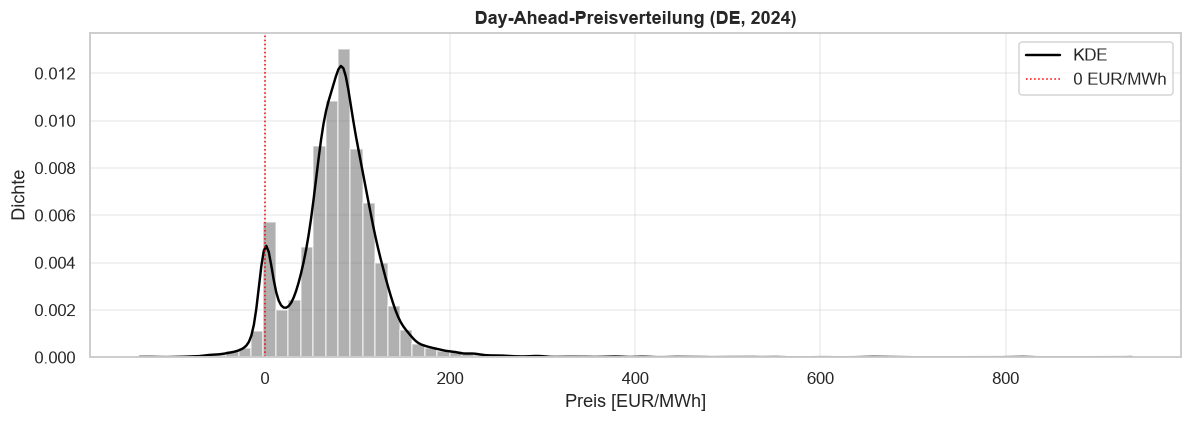

Preis 2024: mean 78.5 | median 79.6 | min -135.4 | max 936.3 EUR/MWh | neg. Std.-Anteil 5.2 %


In [17]:
price24 = price_raw[price_raw.index.year == 2024].dropna()

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(price24.values, bins=80, density=True, color=COLORS["price"], alpha=0.55)
xs = np.linspace(price24.min(), price24.max(), 400)
ax.plot(xs, gaussian_kde(price24.values)(xs), color="black", lw=1.6, label="KDE")
ax.axvline(0, color="red", ls=":", lw=1, label="0 EUR/MWh")
ax.set_xlabel("Preis [EUR/MWh]"); ax.set_ylabel("Dichte")
ax.set_title("Day-Ahead-Preisverteilung (DE, 2024)"); ax.legend()
fig.tight_layout(); savefig(fig, "06_price_distribution"); plt.show()
print(f"Preis 2024: mean {price24.mean():.1f} | median {price24.median():.1f} | "
      f"min {price24.min():.1f} | max {price24.max():.1f} EUR/MWh | "
      f"neg. Std.-Anteil {np.mean(price24.values < 0)*100:.1f} %")

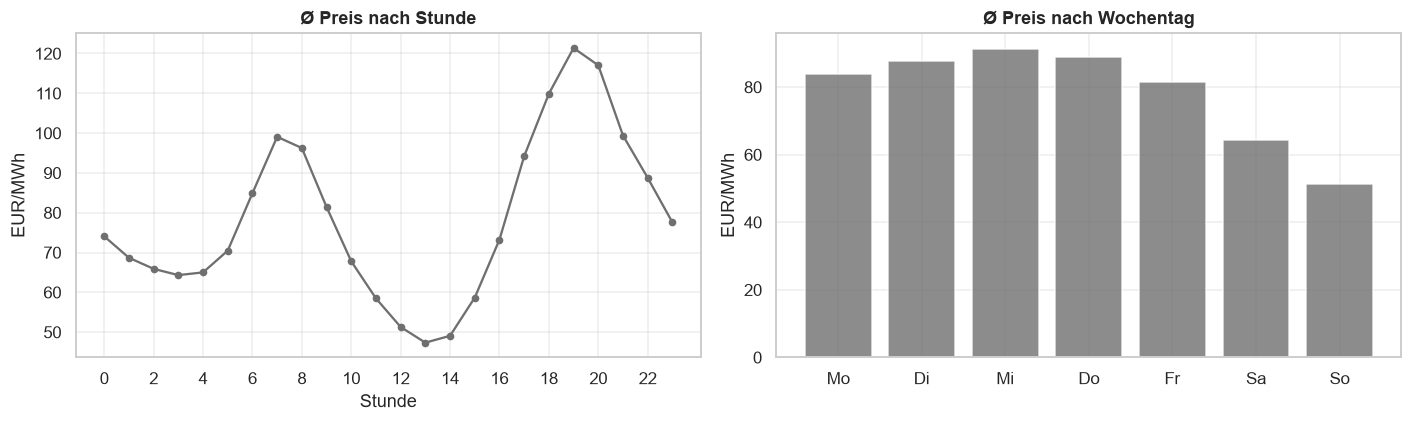

In [18]:
by_hour = price24.groupby(price24.index.hour).mean()
by_dow = price24.groupby(price24.index.dayofweek).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(by_hour.index, by_hour.values, "-o", color=COLORS["price"], ms=4)
axes[0].set_title("Ø Preis nach Stunde"); axes[0].set_xlabel("Stunde")
axes[0].set_ylabel("EUR/MWh"); axes[0].set_xticks(range(0, 24, 2))
axes[1].bar(range(7), by_dow.values, color=COLORS["price"], alpha=0.8)
axes[1].set_title("Ø Preis nach Wochentag"); axes[1].set_xticks(range(7))
axes[1].set_xticklabels(DOW); axes[1].set_ylabel("EUR/MWh")
fig.tight_layout(); savefig(fig, "06_price_by_hour_dow"); plt.show()

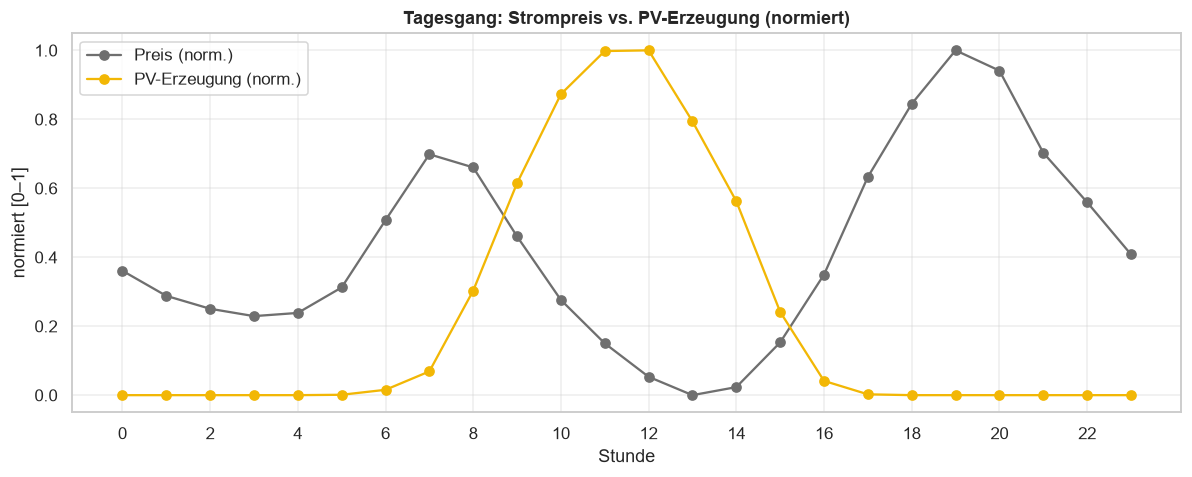

Günstigste Stunden (Ø): 13h=47.4, 14h=49.1, 12h=51.3
Teuerste  Stunden (Ø): 19h=121.4, 20h=117.0, 18h=109.9


In [19]:
pv_by_hour = res["pv"].groupby(res["pv"].index.hour).mean()
norm = lambda s: (s - s.min()) / (s.max() - s.min())

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(by_hour.index, norm(by_hour).values, "-o", color=COLORS["price"], label="Preis (norm.)")
ax.plot(pv_by_hour.index, norm(pv_by_hour).values, "-o", color=COLORS["pv"],
        label="PV-Erzeugung (norm.)")
ax.set_xlabel("Stunde"); ax.set_ylabel("normiert [0–1]"); ax.set_xticks(range(0, 24, 2))
ax.set_title("Tagesgang: Strompreis vs. PV-Erzeugung (normiert)"); ax.legend()
fig.tight_layout(); savefig(fig, "06_price_vs_pv_hourly"); plt.show()

cheap, exp = by_hour.nsmallest(3), by_hour.nlargest(3)
print("Günstigste Stunden (Ø):", ", ".join(f"{h:02d}h={v:.1f}" for h, v in cheap.items()))
print("Teuerste  Stunden (Ø):", ", ".join(f"{h:02d}h={v:.1f}" for h, v in exp.items()))

**Interpretation (Preise).** Der typische Doppelhöcker-Preisverlauf (Morgen-/Abendspitze mit
Mittagsdelle) steht der PV-Mittagsspitze gegenüber: PV drückt die Mittagspreise. Das ist die
ökonomische Grundlage der Demand-Response-Idee — Lasten in die günstige, PV-reiche Mittagszeit
verschieben.

## 7 · Gemeinsame Analyse

Für eine repräsentative Woche: Presse-Leistung, Ofen-Leistung, PV-Erzeugung und Strompreis auf
gemeinsamer Zeitachse (4-Panel) — die visuelle Motivation für Demand Response. Zusätzlich die
Korrelation zwischen PV-Erzeugung und Preis.

> Alle vier Reihen stammen aus **2024** → das 4-Panel zeigt eine echte gemeinsame Kalenderwoche.

Gewaehlte ISO-Woche (max. Pressen-Aktivitaet): 34


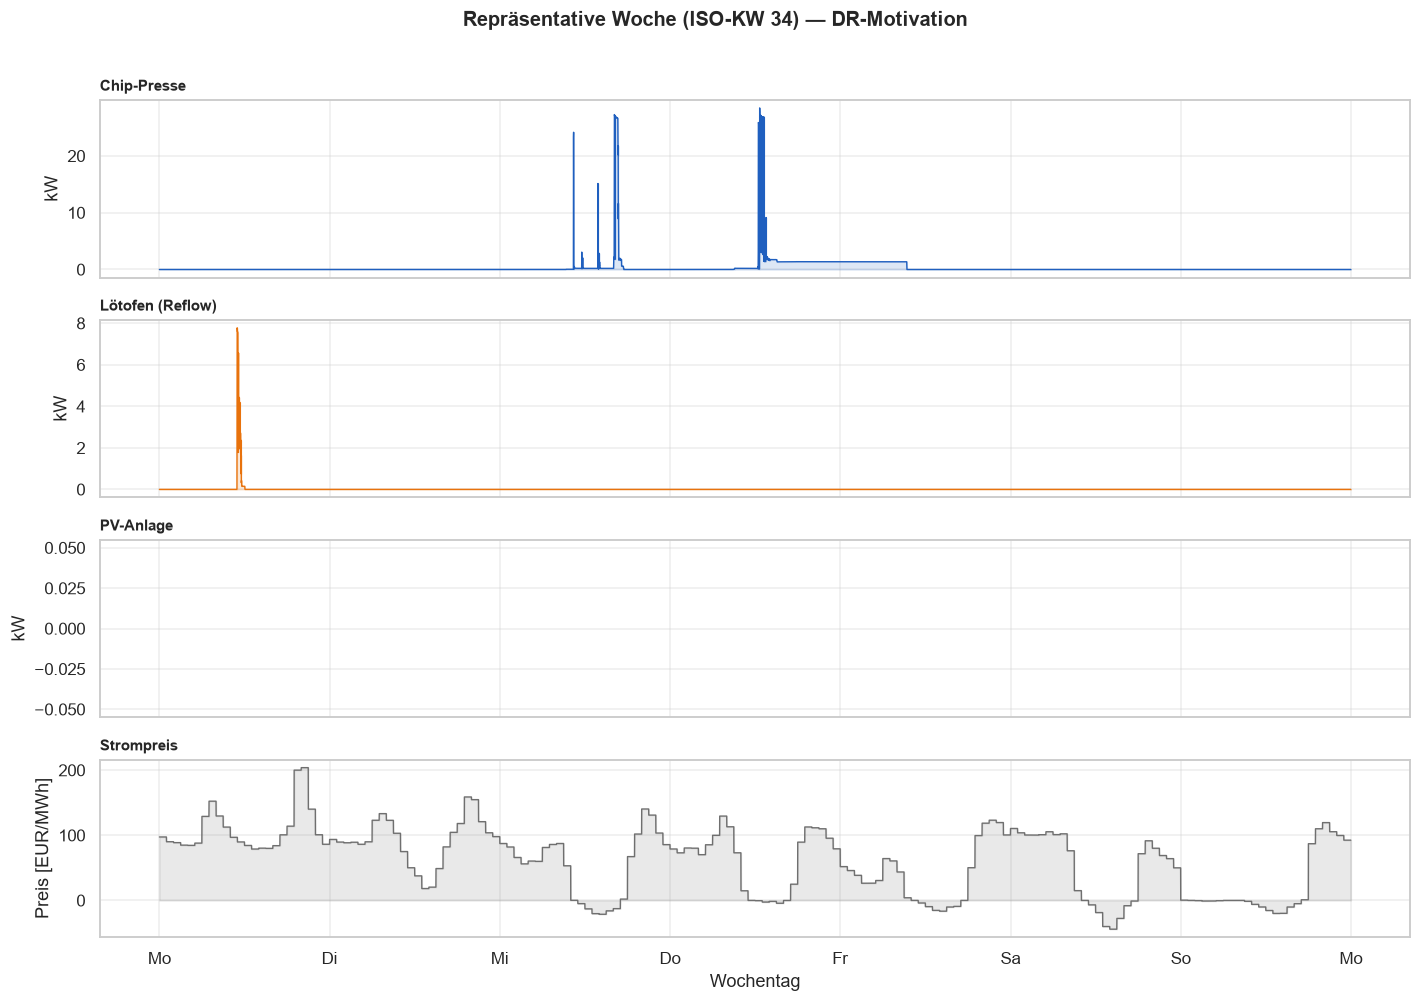

In [20]:
# ---- 4-Panel repraesentative Woche ----------------------------------------
def pick_week_with_activity(series, min_frac=0.02):
    "waehlt eine ISO-Woche mit nennenswerter Aktivitaet der Serie."
    on = (series > 0.1)
    wk = series.index.isocalendar().week.values
    frac = pd.Series(on.values, index=wk).groupby(level=0).mean()
    return int(frac.idxmax())

ISO_WEEK = pick_week_with_activity(res["press"])
print("Gewaehlte ISO-Woche (max. Pressen-Aktivitaet):", ISO_WEEK)

def week_slice(series, wk):
    iso = series.index.isocalendar()
    sub = series[iso.week.values == wk]
    if len(sub) == 0:
        return sub
    origin = sub.index.min().normalize() - pd.Timedelta(days=sub.index.min().dayofweek)
    x = (sub.index - origin).total_seconds() / 86400.0
    return pd.Series(sub.values, index=x)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
panels = [("press", res["press"]), ("oven", res["oven"]), ("pv", res["pv"]),
          ("price", price_1min["press"])]
for ax, (k, s) in zip(axes, panels):
    ws = week_slice(s, ISO_WEEK)
    ax.plot(ws.index, ws.values, color=COLORS[k], lw=0.9)
    ax.fill_between(ws.index, 0, ws.values, color=COLORS[k], alpha=0.15)
    ax.set_ylabel("Preis [EUR/MWh]" if k == "price" else "kW")
    ax.set_title(LABELS[k], loc="left", fontsize=10)
axes[-1].set_xlabel("Wochentag"); axes[-1].set_xticks(range(8))
axes[-1].set_xticklabels(DOW + ["Mo"])
fig.suptitle(f"Repräsentative Woche (ISO-KW {ISO_WEEK}) — DR-Motivation",
             y=1.01, fontsize=13, fontweight="bold")
fig.tight_layout(); savefig(fig, "07_representative_week"); plt.show()

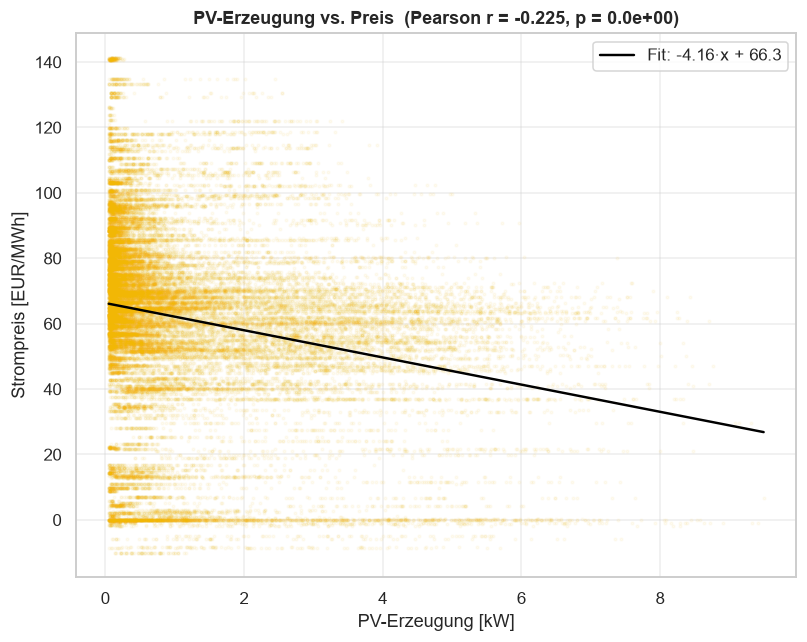

Pearson r = -0.225  (n = 39,107)


In [21]:
# ---- Korrelation PV-Erzeugung vs. Preis -----------------------------------
df_corr = pd.DataFrame({"pv": res["pv"], "price": price_1min["pv"]}).dropna()
df_corr = df_corr[df_corr["pv"] > 0.05]
r, p = pearsonr(df_corr["pv"], df_corr["price"])

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(df_corr["pv"], df_corr["price"], s=3, alpha=0.05, color=COLORS["pv"])
m, b = np.polyfit(df_corr["pv"], df_corr["price"], 1)
xs = np.linspace(df_corr["pv"].min(), df_corr["pv"].max(), 100)
ax.plot(xs, m * xs + b, color="black", lw=1.6, label=f"Fit: {m:.2f}·x + {b:.1f}")
ax.set_xlabel("PV-Erzeugung [kW]"); ax.set_ylabel("Strompreis [EUR/MWh]")
ax.set_title(f"PV-Erzeugung vs. Preis  (Pearson r = {r:.3f}, p = {p:.1e})")
ax.legend(); fig.tight_layout(); savefig(fig, "07_pv_price_scatter"); plt.show()
print(f"Pearson r = {r:.3f}  (n = {len(df_corr):,})")

## Fazit & nächste Schritte

- **Chip-Presse:** hochintermittierender Spitzenlast-Verbraucher (Peaks bis ~29 kW, aktiv < 1 %
  der Zeit) in wenigen Produktionsläufen → als **verschiebbarer Produktionsauftrag** ideal für
  Demand Response; Template als mittlere Leistungs-Hüllkurve je Lauf.
- **Lötofen (Reflow):** klare, wiederkehrende Thermozyklen (Ramp-up/Halten/Abkühlung, Peaks
  ~8,5 kW) → gut als taktbare, verschiebbare Last modellierbar.
- **PV-Anlage:** plausible Erzeugung (Peak ≈ Nennleistung), negativ mit dem Preis korreliert
  (PV drückt Mittagspreise) → Eigenverbrauchs-/Verschiebepotenzial.
- **Strompreis:** ausgeprägter Tagesgang, negative Preise in PV-reichen Stunden → ökonomischer
  Hebel, um Presse- und Ofen-Läufe in günstige, PV-reiche Zeitfenster zu verschieben.